# 13 · Sector comparison: DuPont analysis of return on equity

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/valuein/valuein/blob/main/examples/notebooks/13_sector_comparison.ipynb)

**What you will learn**

- How the DuPont identity splits return on equity (ROE) into margin, asset turnover and leverage.
- How to pull pre-computed ratios for a whole index as of one date.
- How sectors earn their returns differently, and how to find a company that is unusual for its
  sector.

**Plan required:** none (free sample tier).

In [1]:
%pip install -q valuein-sdk matplotlib

Note: you may need to restart the kernel to use updated packages.


## 1. The identity

**ROE = net margin × asset turnover × equity multiplier**

- Net margin (net income / revenue): pricing power and cost control.
- Asset turnover (revenue / total assets): how hard the assets work.
- Equity multiplier (total assets / equity): leverage.

Two companies with the same ROE can get there in opposite ways: a software company through
margin, a retailer through turnover, a bank through leverage. The `ratio` table carries all four
ratios; `signal_panel` takes the latest value known on the date.

In [2]:
import matplotlib.pyplot as plt

from valuein_sdk import ValueinClient

client = ValueinClient()
AS_OF = "2025-06-30"
RATIOS = ["return_on_equity", "net_margin", "asset_turnover", "equity_multiplier"]

panel = client.signal_panel(client.universe(dates=[AS_OF]), ratios=RATIOS, include_price=False)
dupont = panel.dropna(subset=RATIOS)
dupont = dupont[dupont["equity_multiplier"] > 0]  # negative equity makes the decomposition meaningless
print(f"companies with all four ratios on {AS_OF}: {len(dupont)} of {len(panel)}")


Upgrade access:
  Register (free)  → Benchmark: full history for every S&P 500 constituent
  Add API token    → Full US equities universe + complete history

Get your token: https://valuein.biz
  client = ValueinClient()


companies with all four ratios on 2025-06-30: 468 of 499


Check that the identity holds in the data. Each ratio is computed from the same fiscal period's
filing, so the product should match ROE closely; where it does not, the components come from
different periods (one was updated by a later filing) or use different averaging.

In [3]:
product = dupont["net_margin"] * dupont["asset_turnover"] * dupont["equity_multiplier"]
gap = (product - dupont["return_on_equity"]).abs()
print(f"median |product - ROE|: {gap.median():.4f}; within 0.01 for {(gap < 0.01).mean():.0%} of companies")

median |product - ROE|: 0.0000; within 0.01 for 85% of companies


## 2. How each sector earns its return

In [4]:
sectors = dupont.groupby("sector")[RATIOS].median().sort_values("return_on_equity", ascending=False)
sectors["companies"] = dupont.groupby("sector").size()
sectors.round(3)

,return_on_equity,net_margin,asset_turnover,equity_multiplier,companies
sector,,,,,
Consumer Discretionary,0.316,0.085,1.209,3.995,32
Information Technology,0.237,0.161,0.544,2.191,79
Industrials,0.196,0.107,0.662,2.590,90
Communication Services,0.179,0.089,0.455,3.137,11
Health Care,0.168,0.124,0.577,2.200,62
Materials,0.159,0.093,0.629,2.022,25
Energy,0.133,0.116,0.550,1.980,16
Consumer Staples,0.127,0.063,0.838,2.750,30
Financials,0.121,0.180,0.174,3.570,86


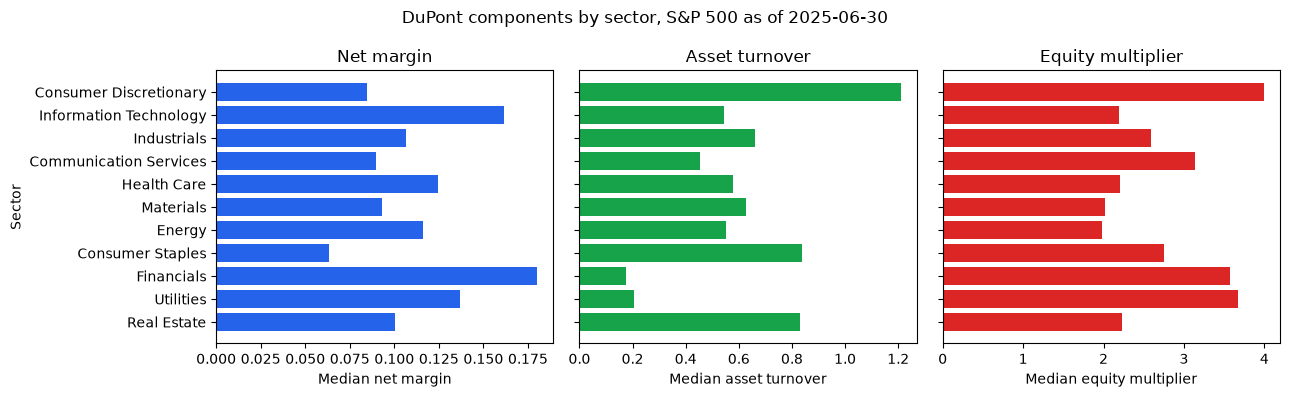

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, column, color in zip(axes, ["net_margin", "asset_turnover", "equity_multiplier"],
                             ["#2563eb", "#16a34a", "#dc2626"]):
    ax.barh(sectors.index, sectors[column], color=color)
    ax.set_xlabel(f"Median {column.replace('_', ' ')}")
    ax.set_title(column.replace("_", " ").capitalize())
axes[0].set_ylabel("Sector")
axes[0].invert_yaxis()
fig.suptitle(f"DuPont components by sector, S&P 500 as of {AS_OF}")
plt.tight_layout()
plt.show()

## 3. The margin and turnover trade-off

Plotted on log scales, companies spread along a diagonal: high margin with low turnover, or the
reverse. A company far above the diagonal for its sector earns both.

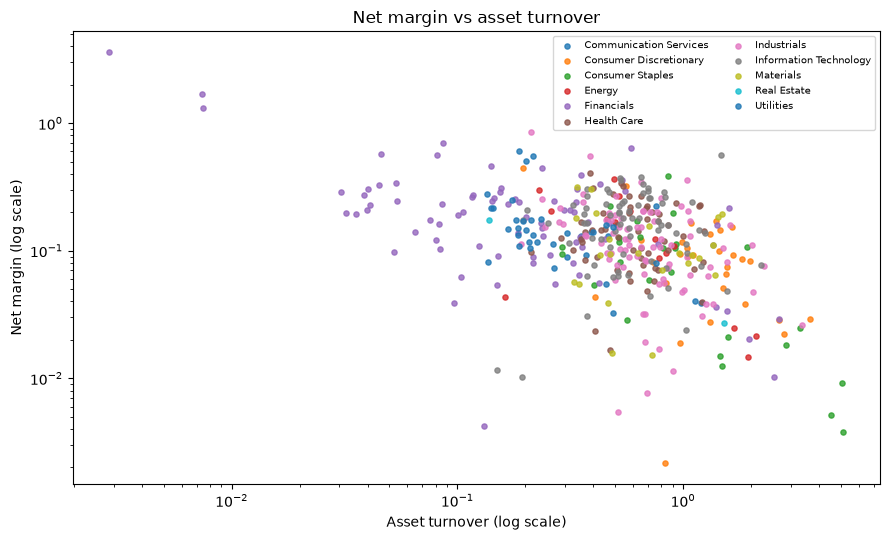

In [6]:
fig, ax = plt.subplots(figsize=(9, 5.5))
positive = dupont[(dupont["net_margin"] > 0) & (dupont["asset_turnover"] > 0)]
for sector, group in positive.groupby("sector"):
    ax.scatter(group["asset_turnover"], group["net_margin"], s=14, label=sector, alpha=0.8)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Asset turnover (log scale)")
ax.set_ylabel("Net margin (log scale)")
ax.set_title("Net margin vs asset turnover")
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

## 4. Unusual for its sector

Rank each component within its sector. A company whose ROE comes mostly from leverage looks
very different from one whose ROE comes from margin, even if the headline ROE is the same.

In [7]:
for column in RATIOS:
    dupont[f"{column}_pct_in_sector"] = dupont.groupby("sector")[column].rank(pct=True)

top_roe = dupont[dupont["return_on_equity_pct_in_sector"] >= 0.9]
top_roe.sort_values("equity_multiplier", ascending=False)[
    ["ticker", "sector", "return_on_equity", "net_margin", "asset_turnover", "equity_multiplier"]
].head(10).round(3)

,ticker,sector,return_on_equity,net_margin,asset_turnover,equity_multiplier
104,COR,Consumer Staples,2.077,0.005,4.534,89.235
214,HCA,Health Care,7.133,0.082,1.220,71.656
244,IRM,Financials,3.874,0.302,0.340,39.613
29,AMP,Financials,0.683,0.190,0.101,35.813
323,MTD,Health Care,8.893,0.223,1.174,34.754
289,LYV,Communication Services,1.308,0.039,1.198,28.205
292,MAR,Consumer Discretionary,2.379,0.095,0.968,25.413
282,LOW,Consumer Discretionary,3.423,0.083,1.971,25.288
416,STX,Information Technology,4.457,0.051,0.857,23.809
293,MAS,Industrials,9.265,0.105,1.508,23.799


In [8]:
client.close()

The list above is the top tenth of each sector by ROE, sorted by leverage: the first names earn
their high ROE mainly through a thin equity base, the last ones mainly through margin or
turnover.

## Next steps

- **[14 · Restatement alpha](14_restatement_alpha.ipynb)**: share prices around restatements.
- Add history: pass several dates to `client.universe(dates=[...])` to see how each sector's
  mix moved over time.